# Beer Reviews EDA

This project explores the global beer market using a comprehensive dataset of 1.5 million reviews from Beer Advocate. We analyze ratings for aroma, taste, appearance, and palate to uncover what defines the world's top-rated beers.

Our goals:
- Identify popular beer styles and trends.
- Spotlight top breweries.
- Understand what factors influence high ratings.


## Importing Libraries and reading data

In [31]:
#Importing packages
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import sklearn as sk
import scipy.stats as ss
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.preprocessing import StandardScaler,MinMaxScaler, LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE, RandomOverSampler

In [32]:
#reading data
beer_data= pd.read_csv('beer_reviews.csv')
beer_data.head()

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,10325,Vecchio Birraio,1234817823,1.5,2.0,2.5,stcules,Hefeweizen,1.5,1.5,Sausa Weizen,5.0,47986
1,10325,Vecchio Birraio,1235915097,3.0,2.5,3.0,stcules,English Strong Ale,3.0,3.0,Red Moon,6.2,48213
2,10325,Vecchio Birraio,1235916604,3.0,2.5,3.0,stcules,Foreign / Export Stout,3.0,3.0,Black Horse Black Beer,6.5,48215
3,10325,Vecchio Birraio,1234725145,3.0,3.0,3.5,stcules,German Pilsener,2.5,3.0,Sausa Pils,5.0,47969
4,1075,Caldera Brewing Company,1293735206,4.0,4.5,4.0,johnmichaelsen,American Double / Imperial IPA,4.0,4.5,Cauldron DIPA,7.7,64883


# Data Cleaning



## Removing Duplicates

We drop the `review_time` column to detect and remove duplicate reviews by the same user for the same beer. This ensures our analysis is not biased by repeated ratings.


In [33]:
#Checking for Duplicates
beer_data.drop(['review_time'], axis=1, inplace=True)
display(pd.DataFrame(beer_data[beer_data.duplicated()]))
print(f"Number of duplicates removed: {beer_data.duplicated().sum()}")
beer_data=beer_data.drop_duplicates(keep='first')

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
1639,1454,Broad Ripple Brew Pub,4.5,3.5,3.5,danielocean03,Märzen / Oktoberfest,4.0,3.5,Oktoberfest,5.50,13289
7506,1386,Harmon Restaurant & Brewery,4.5,4.0,4.0,barleywinefiend,American Double / Imperial IPA,4.5,4.5,Commencement Bay,NaN,66872
7577,1386,Harmon Restaurant & Brewery,4.5,4.5,4.5,barleywinefiend,American Stout,4.5,4.5,Stryker,NaN,73647
7655,1482,The Seven Barrel Brewery,4.0,3.5,3.5,akorsak,American Amber / Red Ale,4.0,3.5,Red 7,NaN,7046
10064,5049,Bath Ales Ltd,4.0,3.5,4.0,wl0307,English Bitter,4.0,4.0,Barnstormer,4.50,13084
...,...,...,...,...,...,...,...,...,...,...,...,...
1575063,364,Maritime Pacific Brewing Company,4.0,4.0,4.0,barleywinefiend,American Double / Imperial IPA,4.0,4.0,Imperial Pale Ale,7.50,957
1582040,429,Alaskan Brewing Co.,4.0,4.0,4.0,JayQue,American IPA,4.0,4.0,Alaskan IPA,6.20,22787
1584107,41,Brouwerij Corsendonk,4.0,4.5,4.0,goindownsouth,Dubbel,4.0,4.0,Corsendonk Pater / Abbey Brown Ale,7.50,138
1585815,3835,Drake's Brewing Co.,4.5,4.0,4.0,rayjay,Russian Imperial Stout,4.5,4.0,Drake's Drakonic Imperial Stout,8.75,12172


Number of duplicates removed: 774


In [34]:
display(pd.DataFrame(beer_data[beer_data.duplicated()]))

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid


**Duplicate entries Deleted**


## Null Values

In [35]:
# Checking Nulls
beer_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1585840 entries, 0 to 1586613
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   brewery_id          1585840 non-null  int64  
 1   brewery_name        1585825 non-null  object 
 2   review_overall      1585840 non-null  float64
 3   review_aroma        1585840 non-null  float64
 4   review_appearance   1585840 non-null  float64
 5   review_profilename  1585493 non-null  object 
 6   beer_style          1585840 non-null  object 
 7   review_palate       1585840 non-null  float64
 8   review_taste        1585840 non-null  float64
 9   beer_name           1585840 non-null  object 
 10  beer_abv            1518078 non-null  float64
 11  beer_beerid         1585840 non-null  int64  
dtypes: float64(6), int64(2), object(4)
memory usage: 157.3+ MB


Text(0, 0.5, 'null values')

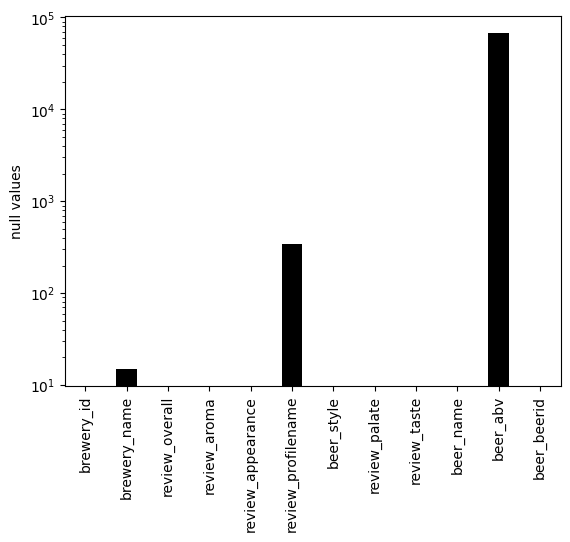

In [36]:
null_counts=beer_data.isnull().sum()
null_counts.plot(kind='bar',color='black')
plt.yscale('log')
plt.ylabel('null values')

**Nulls found in : brewery_name and beer_abv**

$\textbf{Lets start with nulls in brewery_name column}$

In [37]:
display(beer_data[beer_data['brewery_name'].isnull()])

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
651565,1193,NaN,2.0,2.5,2.5,Knapp85,Vienna Lager,1.5,1.5,Engel Tyrolian Bräu WRONG BREWERY SEE SCHWABIS...,5.0,67503
659293,1193,NaN,4.0,4.5,3.5,dqrull,Bock,4.0,3.5,Engel Bock Dunkel WRONG BREWERY SEE CRAILSHEIMER,7.2,63658
659299,1193,NaN,3.5,3.0,3.0,dqrull,Dortmunder / Export Lager,4.0,4.0,Engel Gold WRONG BREWERY SEE CRAILSHEIMER,5.4,63215
659300,1193,NaN,3.5,4.0,3.5,dqrull,Munich Helles Lager,3.5,3.0,Engel Landbier WRONG BREWERY SEE CRAILSHEIMER,4.8,63557
659301,1193,NaN,3.5,4.0,4.0,dqrull,Keller Bier / Zwickel Bier,4.0,3.5,Engel Keller Hell WRONG BREWERY SEE CRAILSHEIMER,5.4,63256
659302,1193,NaN,3.5,4.0,3.0,dqrull,Vienna Lager,3.0,3.5,Engel Aloisius - WRONG BREWERY SEE CRAILSHEIMER,5.9,63459
659303,1193,NaN,3.0,3.0,3.0,Ochsenblut,Keller Bier / Zwickel Bier,2.0,3.0,Engel Keller Dunkel WRONG BREWERY SEE CRAILSH...,5.3,63324
659304,1193,NaN,4.5,4.0,4.0,Dentist666,Keller Bier / Zwickel Bier,4.0,4.5,Engel Keller Dunkel WRONG BREWERY SEE CRAILSH...,5.3,63324
659305,1193,NaN,3.5,3.5,4.0,dqrull,Keller Bier / Zwickel Bier,4.0,4.0,Engel Keller Dunkel WRONG BREWERY SEE CRAILSH...,5.3,63324
1391043,27,NaN,3.5,3.5,3.5,Jason,American Adjunct Lager,4.0,3.5,Hard Hat American Beer,3.8,60


In [38]:
#Replacing Nulls
beer_data.loc[beer_data['brewery_id'] ==1193,'brewery_name'] = 'CRAILSHEIMER' 
beer_data.loc[beer_data['brewery_id'] ==1193,'beer_name']=beer_data.loc[beer_data['brewery_id'] ==1193,'beer_name'].str.replace('WRONG BREWERY SEE CRAILSHEIMER','',regex=True)
beer_data.loc[beer_data['brewery_id'] ==1193,'beer_name']=beer_data.loc[beer_data['brewery_id'] ==1193,'beer_name'].str.replace('WRONG BREWERY SEE SCHWABISCH GMUND','',regex=True)
beer_data['beer_name']=beer_data['beer_name'].str.strip()
beer_data.loc[beer_data['brewery_id'] ==27,'brewery_name'] = 'Unknown' 

In [39]:
#Reviews by style 
review_by_style= beer_data.groupby(['beer_style'])['review_overall','review_aroma','review_taste','review_palate','review_appearance','beer_abv'].mean()

/tmp/ipykernel_229101/1404892529.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  review_by_style= beer_data.groupby(['beer_style'])['review_overall','review_aroma','review_taste','review_palate','review_appearance','beer_abv'].mean()


### beer_abv Nulls

* Replaced with the mean of <code>beer_abv</code>

In [40]:
bd_null= beer_data.loc[beer_data['beer_abv'].isnull(),'beer_abv'].index
beer_data.beer_abv[bd_null]= review_by_style.beer_abv[beer_data.beer_style[bd_null]]
#Final null check
print(beer_data.isnull().sum())

/tmp/ipykernel_229101/721401938.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  beer_data.beer_abv[bd_null]= review_by_style.beer_abv[beer_data.beer_style[bd_null]]


brewery_id              0
brewery_name            0
review_overall          0
review_aroma            0
review_appearance       0
review_profilename    347
beer_style              0
review_palate           0
review_taste            0
beer_name               0
beer_abv                0
beer_beerid             0
dtype: int64


In [41]:
#Removing irrelevant columns 
beer_data.drop(['beer_beerid','brewery_id', 'review_profilename'], axis=1, inplace=True)


## Outliers 

(-1.0, 6.0)

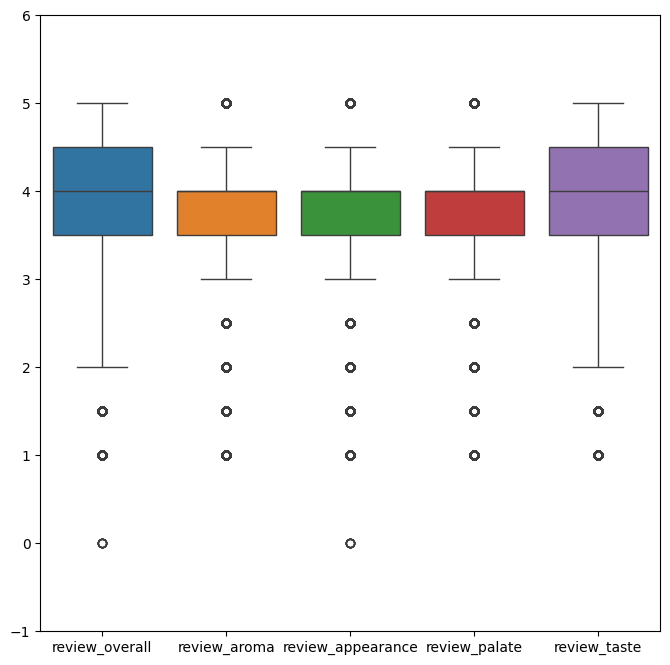

In [12]:
#Outlier detection 
plt.figure(figsize=(8,8))
sns.boxplot(data=beer_data.drop(columns=['beer_abv']))
plt.ylim(-1,6)

* The rows where review values lie below 1 are removed  as reviews should always be above 1

In [42]:
#beer_data_out = beer_data[beer_data.type==float].drop('beer_abv')
for j in beer_data.columns:
    if beer_data[j].dtype == 'float64':
        beer_data= beer_data[beer_data[j]>=1]

(-1.0, 6.0)

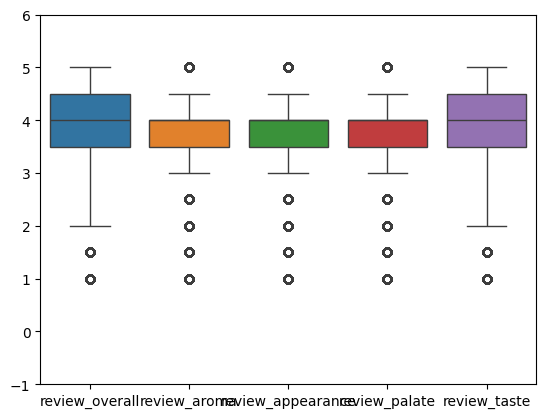

In [43]:
sns.boxplot(data=beer_data.drop(columns=['beer_abv']))
plt.ylim(-1,6)

# EDA

### Correlations

/tmp/ipykernel_229101/2961193758.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(beer_data.corr(), cmap='plasma')


<Axes: >

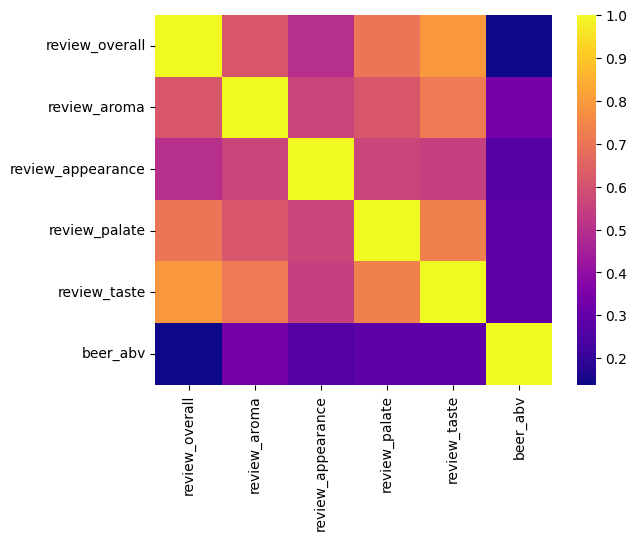

In [15]:
#Let explore the correlation between the variables
sns.heatmap(beer_data.corr(), cmap='plasma')

# Best beer styles

### Insights:
* All the review columns are well correlated with each other whereas a minor corellation can be observed between alcohol percentage and review columns.

 ### Top 10 beer styles

In [47]:
review_by_style= beer_data.groupby(['beer_style'])['review_overall','review_aroma','review_taste','review_palate','review_appearance','beer_abv'].mean()
style_counts = beer_data['beer_style'].value_counts()
review_by_style=review_by_style.reset_index()
review_by_style['style_review_count'] = review_by_style['beer_style'].map(style_counts)
review_by_style

/tmp/ipykernel_229101/613060892.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  review_by_style= beer_data.groupby(['beer_style'])['review_overall','review_aroma','review_taste','review_palate','review_appearance','beer_abv'].mean()


,beer_style,review_overall,review_aroma,review_taste,review_palate,review_appearance,beer_abv,style_review_count
0,Altbier,3.824415,3.624338,3.745185,3.713519,3.809358,5.829155,7737
1,American Adjunct Lager,3.001546,2.480147,2.683005,2.735322,2.788583,4.861857,30726
2,American Amber / Red Ale,3.780864,3.627064,3.695888,3.656479,3.810159,6.031922,45725
3,American Amber / Red Lager,3.564490,3.213318,3.373333,3.354669,3.527431,4.959722,9296
4,American Barleywine,3.896673,4.019311,4.042588,3.996482,4.036469,10.703947,26721
...,...,...,...,...,...,...,...,...
99,Vienna Lager,3.762461,3.433952,3.603654,3.560181,3.698257,5.020328,8948
100,Weizenbock,4.007919,4.044643,4.077381,3.990699,4.009301,8.135389,9408
101,Wheatwine,3.815244,3.968758,3.976838,3.940749,3.906814,10.662830,3713
102,Winter Warmer,3.703839,3.707107,3.718532,3.670532,3.844621,6.585113,20656


In [48]:
#Highest number of reviews
print('Most Popular beer Styles:')
pd.DataFrame(beer_data['beer_style'].value_counts())[:10]

Most Popular beer Styles:


,beer_style
American IPA,117451
American Double / Imperial IPA,85893
American Pale Ale (APA),63426
Russian Imperial Stout,54102
American Double / Imperial Stout,50679
American Porter,50454
American Amber / Red Ale,45725
Belgian Strong Dark Ale,37733
Fruit / Vegetable Beer,33851
American Strong Ale,31933


In [49]:
#Best mean reviews for beer styles
#review_by_style['number_of_reviews']= beer_data['beer_style'].value_counts(sort='beer_style')
best_style={'Best mean overall review':review_by_style.sort_values(by='review_overall',ascending=False).reset_index().loc[0],
       'Best Taste':review_by_style.sort_values(by='review_taste',ascending=False).reset_index().loc[0],
       'Best Aroma':review_by_style.sort_values(by='review_aroma',ascending=False).reset_index().loc[0],
       'Best palate':review_by_style.sort_values(by='review_palate',ascending=False).reset_index().loc[0],
       'Best Appearance':review_by_style.sort_values(by='review_appearance',ascending=False).reset_index().loc[0]
}
pd.DataFrame(best_style).T

,index,beer_style,review_overall,review_aroma,review_taste,review_palate,review_appearance,beer_abv,style_review_count
Best mean overall review,20,American Wild Ale,4.092915,4.126427,4.14962,4.040259,4.005089,7.713437,17785
Best Taste,41,Eisbock,3.977094,4.156778,4.211603,4.113594,3.964514,11.392852,2663
Best Aroma,11,American Double / Imperial Stout,4.029519,4.160372,4.186951,4.098344,4.163381,10.604766,50679
Best palate,86,Quadrupel (Quad),4.071614,4.132528,4.210889,4.124952,4.117901,10.461547,18083
Best Appearance,89,Russian Imperial Stout,4.022873,4.076439,4.149449,4.086734,4.209983,9.98665,54102


### Scaling
* Scaling is required to put the reviews and beer_abv on the same scale

In [19]:
#feature engineering
#review_by_style=review_by_style.reset_index()
X= review_by_style.drop(columns=['beer_style','style_review_count'])
MM= MinMaxScaler()
X_MM = MM.fit_transform(X)


/home/jaim/anaconda3/envs/platonium/lib/python3.9/site-packages/sklearn/utils/_array_api.py:472: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jaim/anaconda3/envs/platonium/lib/python3.9/site-packages/sklearn/utils/_array_api.py:489: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


### The beer style Heatmap
The Heatmap below compares ratings and mean alcohol percentage of all the beer styles.

<Axes: >

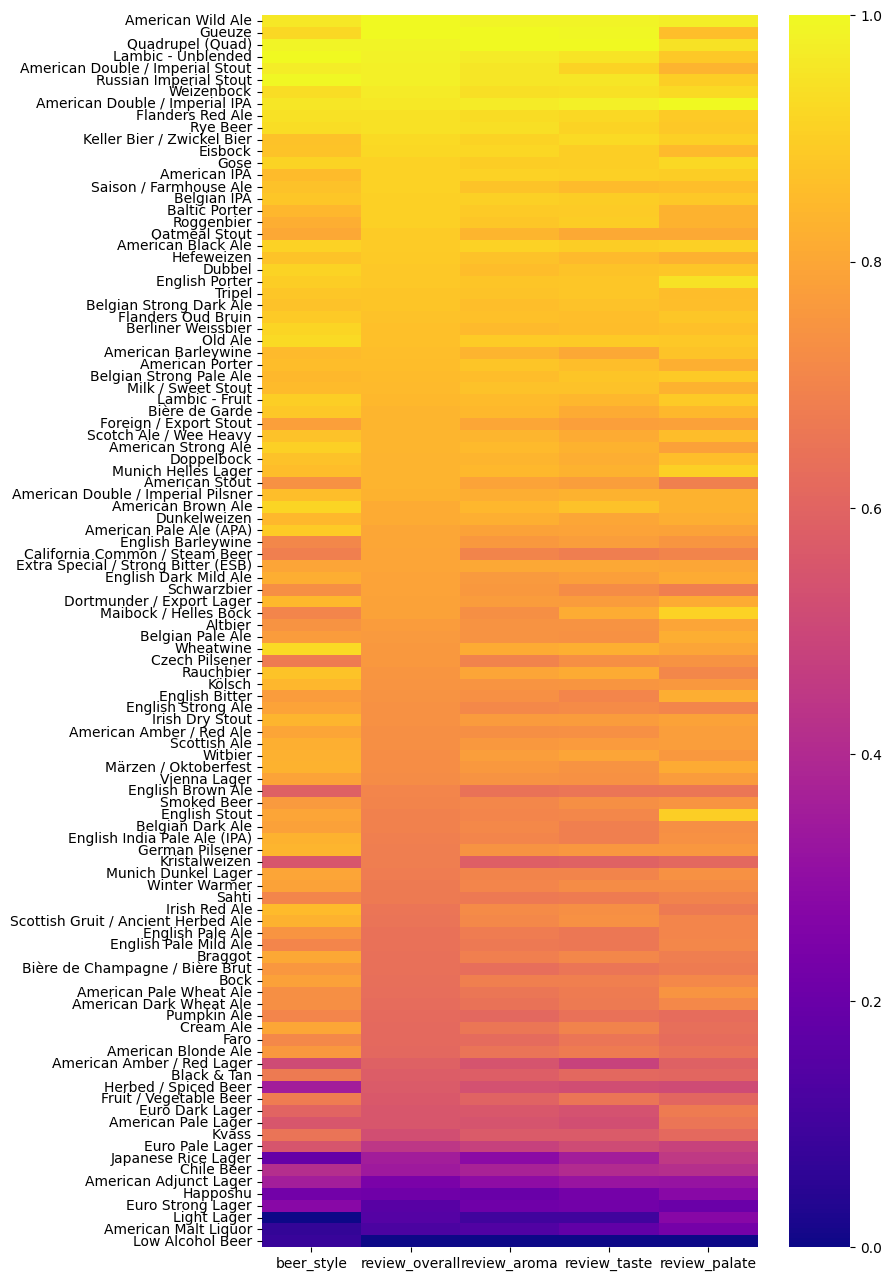

In [20]:
plt.figure(figsize=(8,16))
sns.heatmap(pd.DataFrame(X_MM[:,1:6],columns=review_by_style.columns[1:6]).sort_values(by='review_overall',ascending=False),cmap='plasma',yticklabels=review_by_style.sort_values(by='review_overall',ascending=False).beer_style)

## Insights:
* American Wild Ale is the beer style with the highest overall rating whereas Low alcohol beer is the lowest rated beer style.

## Best Beers

In [21]:
review_by_beer=beer_data.groupby(['beer_name'],sort='beer_name')['review_overall','review_aroma','review_taste','review_palate','review_appearance','beer_abv'].mean()
review_counts = beer_data['beer_name'].value_counts()
review_by_beer=review_by_beer.reset_index()
review_by_beer['beer_review_count'] = review_by_beer['beer_name'].map(review_counts)
print('Most Popular beers:')
display(review_by_beer.sort_values(by='beer_review_count',ascending=False)[:5])
#review_by_beer_data=beer_data.groupby(['beer_name'],sort='beer_name').agg(mean_review_overall=('review_overall','mean'),mean_review_aroma=('review_aroma','mean'),mean_review_taste=('review_taste','mean'),mean_review_palate=('review_palate',mean_review_appearance=('review_appearance','mean'),beer_abv].median()


/tmp/ipykernel_229101/1816600539.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  review_by_beer=beer_data.groupby(['beer_name'],sort='beer_name')['review_overall','review_aroma','review_taste','review_palate','review_appearance','beer_abv'].mean()


Most Popular beers:


,beer_name,review_overall,review_aroma,review_taste,review_palate,review_appearance,beer_abv,beer_review_count
900,90 Minute IPA,4.145338,4.213285,4.325259,4.181140,4.191956,9.000000,3282
26068,India Pale Ale,3.842761,3.758229,3.798019,3.755992,3.856024,6.467234,3129
36774,Old Rasputin Russian Imperial Stout,4.174221,4.198650,4.342173,4.231758,4.373995,9.000000,3111
45693,Sierra Nevada Celebration Ale,4.167391,4.081524,4.188941,4.075175,4.224190,6.800000,2993
52446,Two Hearted Ale,4.329232,4.266067,4.318215,4.137899,4.153324,7.000000,2723


In [22]:
review_by_beer= review_by_beer[review_by_beer.beer_review_count>20]
best_beers={'Best mean overall review':review_by_beer.sort_values(by='review_overall',ascending=False).reset_index().loc[0],
       'Best Taste':review_by_beer.sort_values(by='review_taste',ascending=False).reset_index().loc[0],
       'Best Aroma':review_by_beer.sort_values(by='review_aroma',ascending=False).reset_index().loc[0],
       'Best palate':review_by_beer.sort_values(by='review_palate',ascending=False).reset_index().loc[0],
       'Best Appearance':review_by_beer.sort_values(by='review_appearance',ascending=False).reset_index().loc[0]
}
pd.DataFrame(best_beers).T

,index,beer_name,review_overall,review_aroma,review_taste,review_palate,review_appearance,beer_abv,beer_review_count
Best mean overall review,41159,Rare D.O.S.,4.848485,4.757576,4.848485,4.80303,4.469697,10.604766,33
Best Taste,31301,M Belgian-Style Barleywine,4.75,4.785714,4.857143,4.803571,4.482143,11.6,28
Best Aroma,31301,M Belgian-Style Barleywine,4.75,4.785714,4.857143,4.803571,4.482143,11.6,28
Best palate,31301,M Belgian-Style Barleywine,4.75,4.785714,4.857143,4.803571,4.482143,11.6,28
Best Appearance,10735,Cantillon Blåbær Lambik,4.628205,4.528846,4.628205,4.49359,4.644231,5.0,156


### Best breweries

In [23]:
review_by_brew = beer_data.groupby('brewery_name', sort=True).agg(
    mean_review_overall=('review_overall', 'mean'),
    mean_review_aroma=('review_aroma', 'mean'),
    mean_review_taste=('review_taste', 'mean'),
    mean_review_palate=('review_palate', 'mean'),
    mean_review_appearance=('review_appearance', 'mean'),
    beer_abv=('beer_abv', 'mean'),
    number_of_beers=('beer_name', 'nunique'),
    number_of_reviews= ('brewery_name','count')
)

display("most popular breweries:", review_by_brew.sort_values(by='number_of_reviews',ascending=False)[:5])

'most popular breweries:'

,mean_review_overall,mean_review_aroma,mean_review_taste,mean_review_palate,mean_review_appearance,beer_abv,number_of_beers,number_of_reviews
brewery_name,,,,,,,,
Boston Beer Company (Samuel Adams),3.689435,3.593031,3.647085,3.641303,3.809259,6.406112,133,39433
Dogfish Head Brewery,3.835763,3.916706,3.971082,3.895594,3.943613,9.503279,116,33820
Stone Brewing Co.,4.040084,4.094543,4.150471,4.073404,4.152362,8.251317,134,33043
Sierra Nevada Brewing Co.,4.055942,3.896470,4.028528,3.964962,4.096829,6.908922,140,28726
"Bell's Brewery, Inc.",3.972709,3.938088,4.011282,3.965161,3.983395,7.549706,121,25173


In [24]:
review_by_brew= review_by_brew[review_by_brew.number_of_reviews>20]

best_beers={'Best mean overall review':review_by_brew.sort_values(by='mean_review_overall',ascending=False).reset_index().loc[0],
       'Best Taste':review_by_brew.sort_values(by='mean_review_taste',ascending=False).reset_index().loc[0],
       'Best Aroma':review_by_brew.sort_values(by='mean_review_aroma',ascending=False).reset_index().loc[0],
       'Best palate':review_by_brew.sort_values(by='mean_review_palate',ascending=False).reset_index().loc[0],
       'Best Appearance':review_by_brew.sort_values(by='mean_review_appearance',ascending=False).reset_index().loc[0]
}

pd.DataFrame(best_beers).T

,brewery_name,mean_review_overall,mean_review_aroma,mean_review_taste,mean_review_palate,mean_review_appearance,beer_abv,number_of_beers,number_of_reviews
Best mean overall review,Brauerei Zehendner GmbH,4.607143,4.196429,4.357143,4.375,4.285714,5.583407,3,28
Best Taste,Brouwerij Westvleteren (Sint-Sixtusabdij van W...,4.544996,4.468881,4.58852,4.526493,4.40328,8.808663,5,2378
Best Aroma,The Alchemist,4.581107,4.608779,4.570611,4.388359,4.170802,8.268989,3,524
Best palate,Brouwerij Westvleteren (Sint-Sixtusabdij van W...,4.544996,4.468881,4.58852,4.526493,4.40328,8.808663,5,2378
Best Appearance,Brouwerij Westvleteren (Sint-Sixtusabdij van W...,4.544996,4.468881,4.58852,4.526493,4.40328,8.808663,5,2378


<Figure size 200x2000 with 0 Axes>

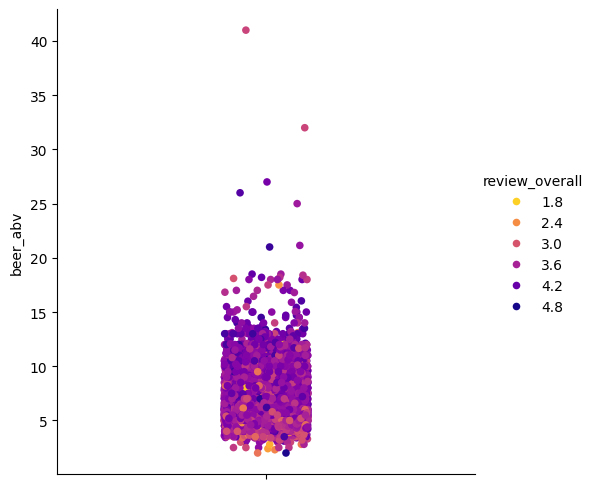

<Figure size 200x2000 with 0 Axes>

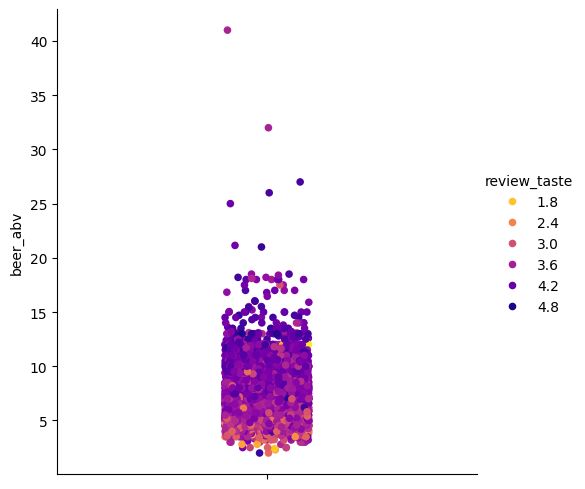

<Figure size 200x2000 with 0 Axes>

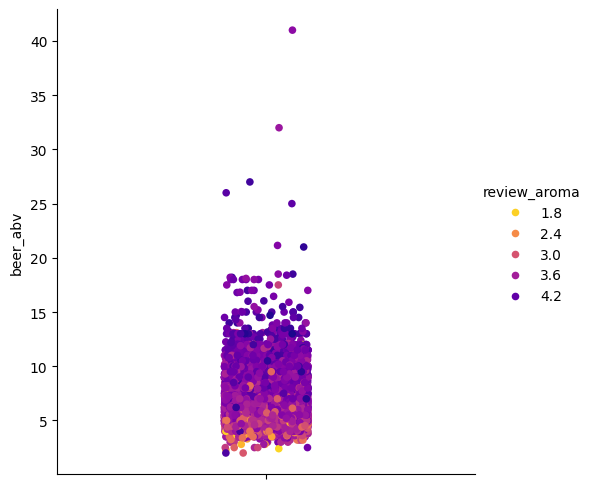

<Figure size 200x2000 with 0 Axes>

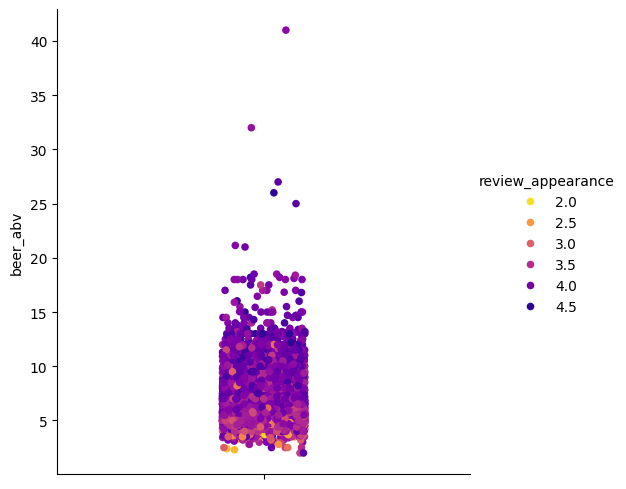

<Figure size 200x2000 with 0 Axes>

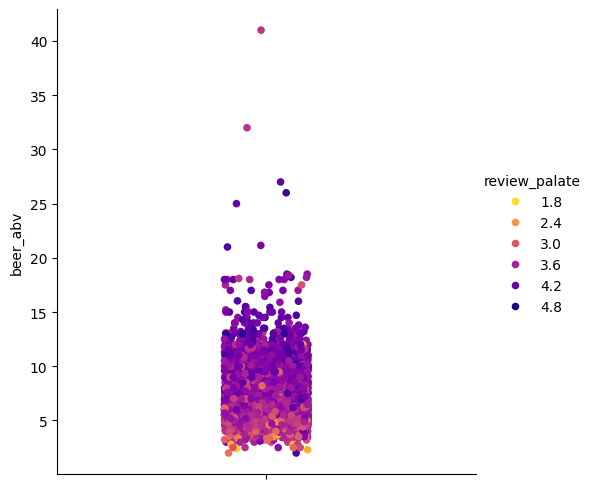

In [25]:

coll=['review_overall','review_taste','review_aroma','review_appearance','review_palate']
for col in coll:
    plt.figure(figsize=(2,20))
    sns.catplot(data=review_by_beer,y='beer_abv',hue=col,palette='plasma_r',s=30)


<Figure size 200x2000 with 0 Axes>

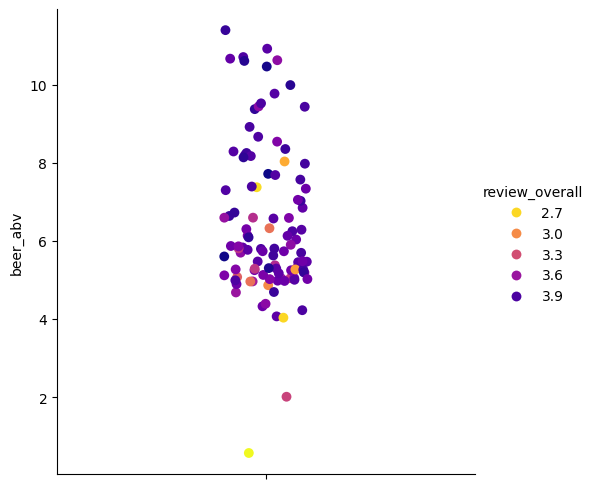

<Figure size 200x2000 with 0 Axes>

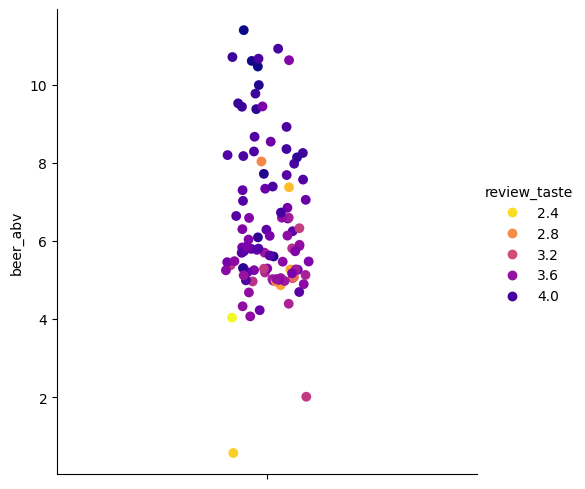

<Figure size 200x2000 with 0 Axes>

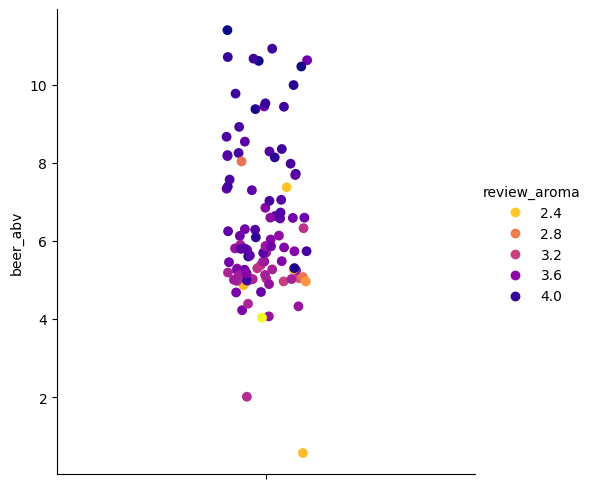

<Figure size 200x2000 with 0 Axes>

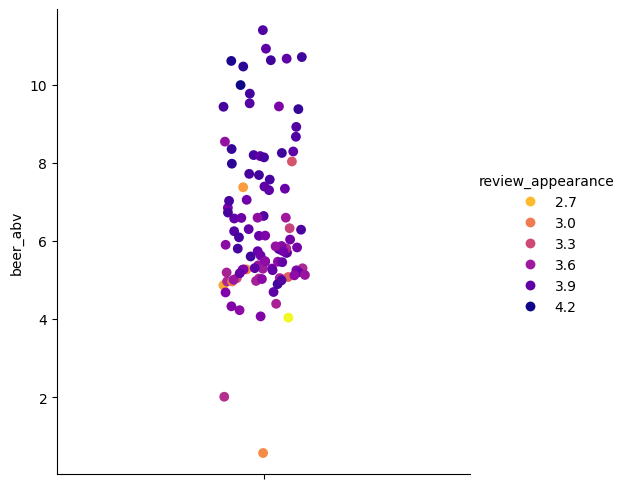

<Figure size 200x2000 with 0 Axes>

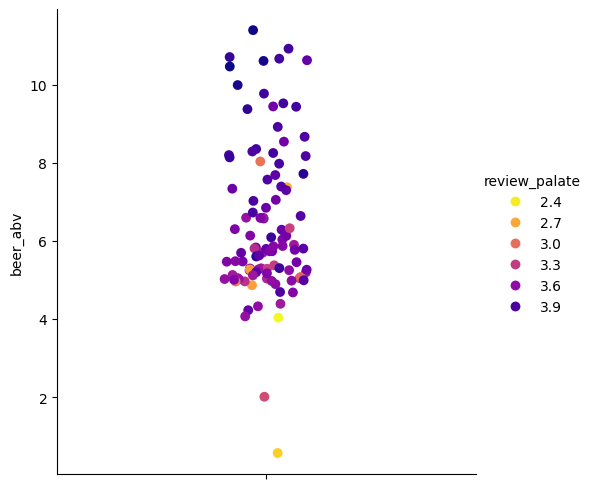

In [26]:

coll=['review_overall','review_taste','review_aroma','review_appearance','review_palate']
for col in coll:
    plt.figure(figsize=(2,20))
    sns.catplot(data=review_by_style,y='beer_abv',hue=col,palette='plasma_r',s=50)


* There are very few low alcohol beers that are highly rated and vice versa

## Results
1. **Dataset Overview and Preprocessing**
* The dataset included comprehensive detailed fields: brewery name, beer style, review aspect scores (aroma, taste, appearance, palate, and overall), and alcohol by volume (ABV).

* Missing ABV values were effectively imputed using the mean ABV for each beer style, and non-informative columns were removed, resulting in a focused and consistent analytical base.

2. **Most Popular Beer Styles**
* American IPA is the most extensively reviewed beer style, with over 117,000 reviews, indicating its leading popularity. This is followed by:

   * American Double / Imperial IPA: 85,893 reviews.

   * American Pale Ale (APA): 63,426 reviews.

* Other notable styles: Russian Imperial Stout, American Double/Imperial Stout, American Porter.

* **High review volume of American beer suggests an overfitting towards American taste buds as expected due to majority of American reviewers on Beer Advocate** 

3. **Top-Rated Beer Styles by Review Category**
* American wild Ale had the highest mean overall score (3.82), indicating strong quality perception.

* Eisbock led in taste (mean score 4.21).

* American Double / Imperial Stout was top for aroma (mean score 4.19).

* Quadrupel (Quad) led palate (mean score 4.21).

* Russian Imperial Stout topped appearance (mean score 4.15).

* These findings show an appreciation for both classic European and bold American beer styles.

4. **Top-Rated Individual Beers**
* Rare D.O.S. achieved the best mean overall review (4.85).

* M Belgian-Style Barleywine obtained highest marks for taste, aroma, and palate categories.

* Cantillon Blåbær Lambik scored highest for visual appearance.

5. **Leading Breweries**
* By review volume: Boston Beer Company (Samuel Adams) had the most reviews (39,433, across 133 beers), followed by Dogfish Head Brewery and Stone Brewing Co.

* By rating quality: Brauerei Zehendner GmbH had the highest average overall rating (4.61), while niche European breweries like Brouwerij Westvleteren dominated taste, palate, and appearance subcategories.

* The Alchemist led for aroma.

6. **Strength of Beer and Review Scores**
* Beers with higher ABV (above 8%) such as Barleywines, Imperial Stouts, and Quads received higher average review scores for taste and palate, suggesting a preference among seasoned reviewers for strong, complex brews.

